# Capítulo 13 — Probabilidades, umbrales, ROC y AUC

En los capítulos anteriores evaluamos clases predichas mediante la matriz de confusión, la accuracy, la precision, el recall y el F1-score. En este cuaderno conservaremos esas herramientas, pero trabajaremos con una salida más rica: las probabilidades estimadas por el modelo.

Primero observaremos cómo un umbral transforma probabilidades en clases. Luego construiremos la curva ROC, calcularemos AUC y analizaremos qué información aportan —y qué información no aportan— estas herramientas.


## Objetivos del cuaderno

Al finalizar este cuaderno, deberías poder:

- distinguir una clase predicha de una probabilidad estimada;
- explicar cómo el umbral transforma probabilidades en decisiones;
- calcular sensibilidad, especificidad y tasa de falsos positivos;
- interpretar los ejes y los puntos de una curva ROC;
- calcular e interpretar ROC-AUC;
- comparar clasificadores mediante sus curvas ROC con prudencia;
- reconocer por qué AUC no elige un umbral ni reemplaza la matriz de confusión;
- identificar cuándo una curva Precision-Recall puede aportar información adicional.


## 1. Importar las herramientas

Usaremos el mismo conjunto de datos y el mismo tipo de modelo de los cuadernos 11 y 12. También incorporaremos las funciones necesarias para calcular las curvas ROC y Precision-Recall.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import (
    load_breast_cancer,
    make_classification,
)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier


## 2. Preparar un problema de clasificación conocido

Continuaremos con el dataset Breast Cancer Wisconsin. Cada fila contiene mediciones obtenidas a partir de imágenes digitalizadas de muestras celulares.

Como en los cuadernos anteriores, redefiniremos los códigos para que:

```text
0 → muestra benigna
1 → muestra maligna
```

Este dataset se utiliza exclusivamente con fines educativos. Los resultados del cuaderno no constituyen una herramienta médica ni deben usarse para tomar decisiones clínicas.


In [2]:
datos = load_breast_cancer(as_frame=True)

X = datos.data

# En el dataset original, 0 significa maligno y 1 benigno.
# Reordenamos los códigos para definir "maligna" como clase positiva.
y = (datos.target == 0).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y,
)

pd.DataFrame({
    "conjunto": ["Entrenamiento", "Prueba"],
    "filas": [len(y_train), len(y_test)],
    "casos_malignos": [y_train.sum(), y_test.sum()],
    "porcentaje_malignos": [
        y_train.mean() * 100,
        y_test.mean() * 100,
    ],
}).round(1)


,conjunto,filas,casos_malignos,porcentaje_malignos
0,Entrenamiento,426,159,37.3
1,Prueba,143,53,37.1


La separación conserva prácticamente la misma proporción de muestras malignas en ambos conjuntos. El conjunto de prueba contiene 143 casos, de los cuales 53 pertenecen a la clase positiva.


In [3]:
modelo_logistico = Pipeline([
    ("escalador", StandardScaler()),
    ("logistica", LogisticRegression(
        max_iter=1000,
        random_state=42,
    )),
])

modelo_logistico.fit(X_train, y_train)

print("Modelo entrenado.")


Modelo entrenado.


La regresión logística y el `Pipeline` ya fueron estudiados. Aquí no volveremos a explicar su funcionamiento: utilizaremos el modelo como fuente de probabilidades para concentrarnos en la evaluación.


## 3. Comparar clases y probabilidades

`predict()` devuelve una clase final. `predict_proba()` devuelve una probabilidad para cada clase. Antes de elegir una columna, conviene comprobar el orden de las clases aprendido por el modelo.


In [4]:
probabilidades = modelo_logistico.predict_proba(X_test)
clases_modelo = modelo_logistico.named_steps[
    "logistica"
].classes_

print("Orden de las clases:", clases_modelo)
print("Forma de la matriz:", probabilidades.shape)


Orden de las clases: [0 1]
Forma de la matriz: (143, 2)


El orden es `[0, 1]`. Por lo tanto, la primera columna contiene la probabilidad estimada de la clase benigna y la segunda, la probabilidad estimada de la clase maligna.


In [5]:
prob_maligna = probabilidades[:, 1]
pred_umbral_05 = (
    prob_maligna >= 0.5
).astype(int)

tabla_probabilidades = pd.DataFrame({
    "clase_real": y_test.map({
        0: "Benigna",
        1: "Maligna",
    }).to_numpy(),
    "P_benigna": probabilidades[:, 0],
    "P_maligna": prob_maligna,
    "predicción_umbral_0,5": np.where(
        pred_umbral_05 == 1,
        "Maligna",
        "Benigna",
    ),
})

tabla_ordenada = tabla_probabilidades.sort_values(
    "P_maligna"
).reset_index(drop=True)

posiciones = np.linspace(
    0,
    len(tabla_ordenada) - 1,
    10,
    dtype=int,
)

tabla_ordenada.iloc[posiciones].round(3)


,clase_real,P_benigna,P_maligna,"predicción_umbral_0,5"
0,Benigna,1.000,0.000,Benigna
15,Benigna,1.000,0.000,Benigna
31,Benigna,1.000,0.000,Benigna
47,Benigna,0.998,0.002,Benigna
63,Benigna,0.992,0.008,Benigna
78,Benigna,0.950,0.050,Benigna
94,Benigna,0.462,0.538,Maligna
110,Maligna,0.005,0.995,Maligna
126,Maligna,0.000,1.000,Maligna
142,Maligna,0.000,1.000,Maligna


La tabla recorre casos con probabilidades muy bajas, intermedias y muy altas. Dos casos pueden recibir la misma clase final y, sin embargo, estar a distancias muy distintas del umbral.

La probabilidad permite conservar ese matiz. Aun así, sigue siendo una estimación del modelo, no una certeza sobre cada caso.


In [6]:
sumas_por_fila = probabilidades.sum(axis=1)
predicciones_modelo = modelo_logistico.predict(X_test)

print(
    "Suma mínima de probabilidades:",
    f"{sumas_por_fila.min():.3f}",
)
print(
    "Suma máxima de probabilidades:",
    f"{sumas_por_fila.max():.3f}",
)
print(
    "¿predict coincide con el umbral 0,5?",
    np.array_equal(
        predicciones_modelo,
        pred_umbral_05,
    ),
)


Suma mínima de probabilidades: 1.000
Suma máxima de probabilidades: 1.000
¿predict coincide con el umbral 0,5? True


En este problema binario, las probabilidades de ambas clases suman 1. Además, `predict()` coincide con aplicar el umbral `0,5` sobre la probabilidad de la clase positiva.


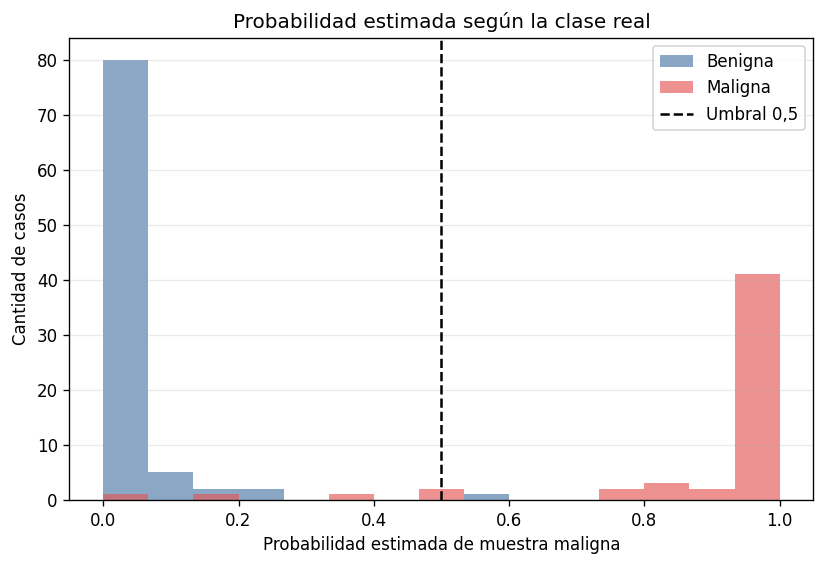

In [7]:
limites = np.linspace(0, 1, 16)

plt.figure(figsize=(8, 5))
plt.hist(
    prob_maligna[y_test.to_numpy() == 0],
    bins=limites,
    alpha=0.65,
    label="Benigna",
    color="#4C78A8",
)
plt.hist(
    prob_maligna[y_test.to_numpy() == 1],
    bins=limites,
    alpha=0.65,
    label="Maligna",
    color="#E45756",
)
plt.axvline(
    0.5,
    color="black",
    linestyle="--",
    label="Umbral 0,5",
)
plt.title(
    "Probabilidad estimada según la clase real"
)
plt.xlabel(
    "Probabilidad estimada de muestra maligna"
)
plt.ylabel("Cantidad de casos")
plt.grid(axis="y", alpha=0.25)
plt.legend()
plt.show()


La mayor parte de las muestras benignas recibe probabilidades bajas y la mayor parte de las malignas, probabilidades altas. Los casos ubicados en la zona de superposición son los más difíciles de separar mediante un único punto de corte.


## 4. Mover el umbral de clasificación

El modelo ya calculó sus probabilidades. Cambiar el umbral no vuelve a entrenarlo: modifica la regla con la que transformamos esas probabilidades en clases.

Para cada umbral observaremos verdaderos positivos, falsos positivos, falsos negativos, sensibilidad, especificidad y tasa de falsos positivos.


In [8]:
umbrales = [0.1, 0.3, 0.5, 0.7, 0.9]
resultados_umbrales = []

for umbral in umbrales:
    predicciones = (
        prob_maligna >= umbral
    ).astype(int)

    vn, fp, fn, vp = confusion_matrix(
        y_test,
        predicciones,
        labels=[0, 1],
    ).ravel()

    sensibilidad = vp / (vp + fn)
    especificidad = vn / (vn + fp)

    resultados_umbrales.append({
        "umbral": umbral,
        "positivos_predichos": vp + fp,
        "VP": vp,
        "FP": fp,
        "FN": fn,
        "sensibilidad": sensibilidad,
        "especificidad": especificidad,
        "tasa_FP": 1 - especificidad,
    })

tabla_umbrales = pd.DataFrame(
    resultados_umbrales
)

tabla_umbrales.round(3)


,umbral,positivos_predichos,VP,FP,FN,sensibilidad,especificidad,tasa_FP
0,0.1,58,52,6,1,0.981,0.933,0.067
1,0.3,52,51,1,2,0.962,0.989,0.011
2,0.5,50,49,1,4,0.925,0.989,0.011
3,0.7,48,48,0,5,0.906,1.000,0.000
4,0.9,43,43,0,10,0.811,1.000,0.000


La tendencia coincide con lo desarrollado en el capítulo:

- con umbral `0,1`, el modelo detecta 52 de las 53 muestras malignas, pero genera seis falsas alarmas;
- con umbral `0,9`, no genera falsos positivos, pero deja sin detectar diez muestras malignas;
- los umbrales intermedios producen otros equilibrios.

Un umbral más bajo tiende a aumentar la sensibilidad. Un umbral más alto puede aumentar la especificidad.


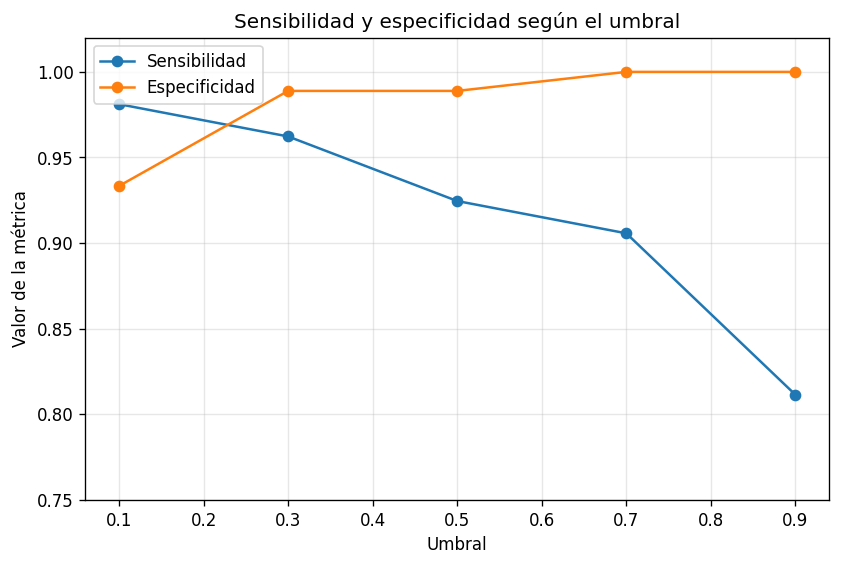

In [9]:
plt.figure(figsize=(8, 5))

plt.plot(
    tabla_umbrales["umbral"],
    tabla_umbrales["sensibilidad"],
    marker="o",
    label="Sensibilidad",
)
plt.plot(
    tabla_umbrales["umbral"],
    tabla_umbrales["especificidad"],
    marker="o",
    label="Especificidad",
)

plt.title(
    "Sensibilidad y especificidad según el umbral"
)
plt.xlabel("Umbral")
plt.ylabel("Valor de la métrica")
plt.ylim(0.75, 1.02)
plt.grid(alpha=0.3)
plt.legend()
plt.show()


El gráfico no señala un umbral universalmente correcto. Elegirlo exige considerar qué error tiene mayores consecuencias y cuántas alertas pueden revisarse en el contexto real.


## 5. Calcular sensibilidad y especificidad

Retomemos el umbral `0,5` para reconstruir ambas métricas desde la matriz de confusión:

```text
sensibilidad = VP / (VP + FN)
especificidad = VN / (VN + FP)
```


In [10]:
vn_05, fp_05, fn_05, vp_05 = (
    confusion_matrix(
        y_test,
        pred_umbral_05,
        labels=[0, 1],
    ).ravel()
)

sensibilidad_manual = (
    vp_05 / (vp_05 + fn_05)
)
especificidad_manual = (
    vn_05 / (vn_05 + fp_05)
)

pd.DataFrame({
    "VP": [vp_05],
    "FN": [fn_05],
    "VN": [vn_05],
    "FP": [fp_05],
    "sensibilidad": [sensibilidad_manual],
    "recall_sklearn": [
        recall_score(
            y_test,
            pred_umbral_05,
        )
    ],
    "especificidad": [especificidad_manual],
}).round(3)


,VP,FN,VN,FP,sensibilidad,recall_sklearn,especificidad
0,49,4,89,1,0.925,0.925,0.989


La sensibilidad es `0,925`: el modelo detectó 49 de las 53 muestras malignas. Coincide con el recall porque ambos nombres describen la misma métrica.

La especificidad es `0,989`: el modelo clasificó correctamente 89 de las 90 muestras benignas.


In [11]:
tasa_fp_manual = (
    fp_05 / (fp_05 + vn_05)
)

print(
    "Tasa de falsos positivos:",
    f"{tasa_fp_manual:.3f}",
)
print(
    "1 - especificidad:",
    f"{1 - especificidad_manual:.3f}",
)


Tasa de falsos positivos: 0.011
1 - especificidad: 0.011


La tasa de falsos positivos es el complemento de la especificidad. Esta relación será central en la curva ROC:

```text
tasa de falsos positivos = 1 - especificidad
```


## 6. Construir la curva ROC

Cada umbral produce un par de valores:

```text
eje horizontal → tasa de falsos positivos
eje vertical   → sensibilidad
```

Los cinco umbrales que ya probamos pueden interpretarse como cinco puntos del plano ROC.


In [12]:
puntos_seleccionados = tabla_umbrales[[
    "umbral",
    "tasa_FP",
    "sensibilidad",
    "FP",
    "FN",
]].copy()

puntos_seleccionados.round(3)


,umbral,tasa_FP,sensibilidad,FP,FN
0,0.1,0.067,0.981,6,1
1,0.3,0.011,0.962,1,2
2,0.5,0.011,0.925,1,4
3,0.7,0.000,0.906,0,5
4,0.9,0.000,0.811,0,10


Al bajar el umbral, el punto suele desplazarse hacia arriba y hacia la derecha: aumenta la detección de positivos, pero también pueden aumentar las falsas alarmas sobre los negativos.


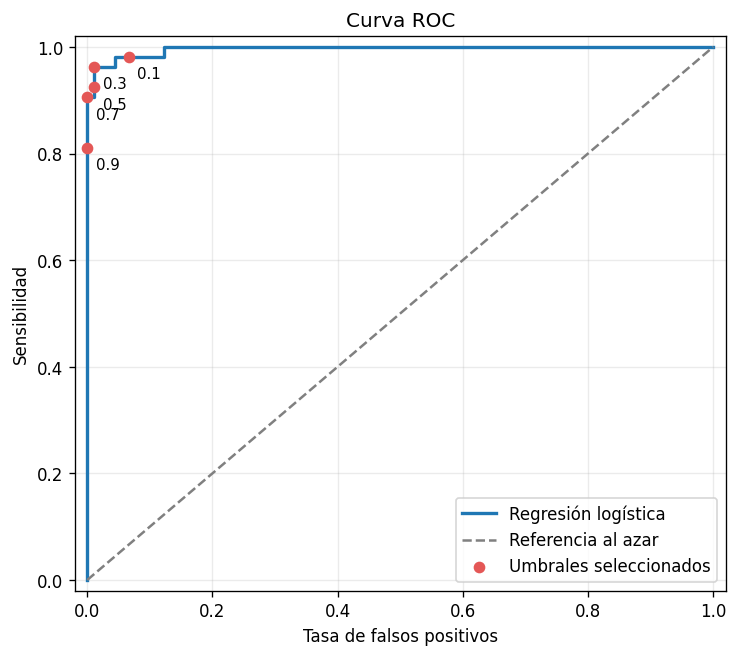

In [13]:
fpr_log, tpr_log, umbrales_roc_log = (
    roc_curve(
        y_test,
        prob_maligna,
    )
)

plt.figure(figsize=(7, 6))
plt.plot(
    fpr_log,
    tpr_log,
    linewidth=2,
    label="Regresión logística",
)
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="Referencia al azar",
)
plt.scatter(
    tabla_umbrales["tasa_FP"],
    tabla_umbrales["sensibilidad"],
    color="#E45756",
    zorder=3,
    label="Umbrales seleccionados",
)

for _, fila in tabla_umbrales.iterrows():
    plt.annotate(
        f"{fila['umbral']:.1f}",
        (
            fila["tasa_FP"],
            fila["sensibilidad"],
        ),
        xytext=(5, -13),
        textcoords="offset points",
        fontsize=9,
    )

plt.title("Curva ROC")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Sensibilidad")
plt.xlim(-0.02, 1.02)
plt.ylim(-0.02, 1.02)
plt.grid(alpha=0.25)
plt.legend(loc="lower right")
plt.show()


La curva se acerca a la esquina superior izquierda: el modelo logra alta sensibilidad con una tasa de falsos positivos baja en varios umbrales.

La diagonal representa una separación parecida al azar. La curva ROC permite observar muchos puntos de corte, pero no decide cuál debe usarse.


## 7. Resumir la curva mediante AUC

ROC-AUC es el área bajo la curva ROC. Se calcula con las probabilidades o puntuaciones del modelo, no con una única clase predicha.


In [14]:
auc_logistico = roc_auc_score(
    y_test,
    prob_maligna,
)

print(
    "ROC-AUC de la regresión logística:",
    f"{auc_logistico:.3f}",
)


ROC-AUC de la regresión logística: 0.996


El ROC-AUC es aproximadamente `0,996`, muy cercano a 1. En este conjunto de prueba, el modelo logra separar muy bien las clases.

Este resultado no demuestra que el clasificador sea perfecto ni que mantenga el mismo desempeño con datos nuevos de otro contexto.


In [15]:
prob_positivos = prob_maligna[
    y_test.to_numpy() == 1
]
prob_negativos = prob_maligna[
    y_test.to_numpy() == 0
]

resultados_pares = []

for prob_positiva in prob_positivos:
    for prob_negativa in prob_negativos:
        if prob_positiva > prob_negativa:
            resultados_pares.append(1)
        elif prob_positiva == prob_negativa:
            resultados_pares.append(0.5)
        else:
            resultados_pares.append(0)

proporcion_pares_ordenados = np.mean(
    resultados_pares
)

print(
    "Proporción de pares ordenados:",
    f"{proporcion_pares_ordenados:.3f}",
)
print(
    "ROC-AUC:",
    f"{auc_logistico:.3f}",
)


Proporción de pares ordenados: 0.996
ROC-AUC: 0.996


Los resultados coinciden. Una interpretación útil de AUC es la probabilidad de que el modelo asigne una puntuación mayor a un positivo real que a un negativo real elegidos al azar. Los empates aportan medio punto.

Esta interpretación se refiere al ordenamiento de los casos. No garantiza que cada valor de probabilidad esté perfectamente calibrado.


## 8. Comparar dos modelos conocidos

Entrenaremos también un árbol de profundidad 2, similar a los estudiados en el Capítulo 10. El objetivo no es buscar el mejor modelo, sino comprobar que las curvas ROC y AUC permiten comparar su capacidad de separación sobre los mismos datos de prueba.


In [16]:
modelo_arbol = DecisionTreeClassifier(
    max_depth=2,
    random_state=42,
)
modelo_arbol.fit(X_train, y_train)

prob_arbol = modelo_arbol.predict_proba(
    X_test
)[:, 1]

auc_arbol = roc_auc_score(
    y_test,
    prob_arbol,
)

pd.DataFrame({
    "modelo": [
        "Regresión logística",
        "Árbol de profundidad 2",
    ],
    "ROC_AUC": [
        auc_logistico,
        auc_arbol,
    ],
}).round(3)


,modelo,ROC_AUC
0,Regresión logística,0.996
1,Árbol de profundidad 2,0.880


En esta única separación de datos, la regresión logística obtiene un AUC mayor. Esto indica que sus puntuaciones ordenan mejor las muestras malignas por encima de las benignas.

No es una conclusión universal sobre ambos algoritmos. Los resultados dependen de los datos, las variables, la configuración y la forma de evaluación.


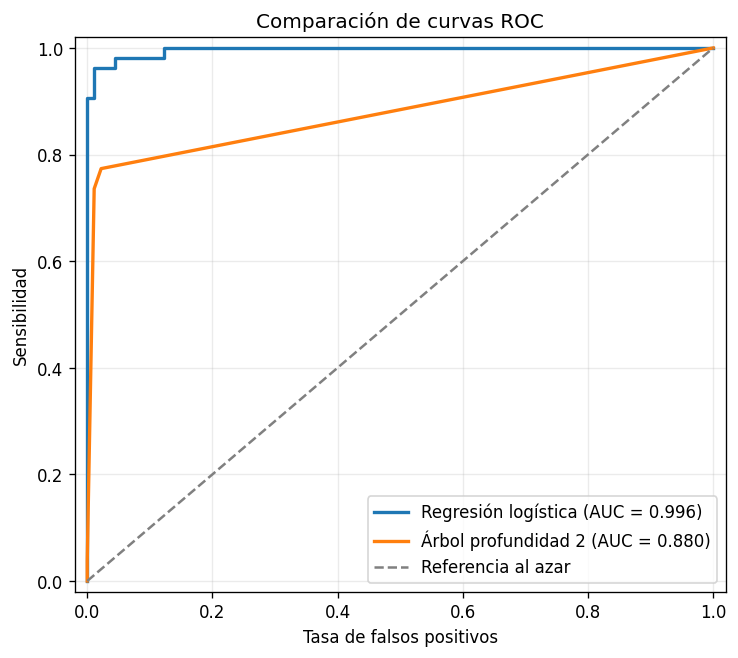

In [17]:
fpr_arbol, tpr_arbol, _ = roc_curve(
    y_test,
    prob_arbol,
)

plt.figure(figsize=(7, 6))
plt.plot(
    fpr_log,
    tpr_log,
    linewidth=2,
    label=(
        "Regresión logística "
        f"(AUC = {auc_logistico:.3f})"
    ),
)
plt.plot(
    fpr_arbol,
    tpr_arbol,
    linewidth=2,
    label=(
        "Árbol profundidad 2 "
        f"(AUC = {auc_arbol:.3f})"
    ),
)
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="Referencia al azar",
)

plt.title("Comparación de curvas ROC")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Sensibilidad")
plt.xlim(-0.02, 1.02)
plt.ylim(-0.02, 1.02)
plt.grid(alpha=0.25)
plt.legend(loc="lower right")
plt.show()


El árbol produce pocos valores de probabilidad distintos, por eso su curva tiene escalones más grandes. La regresión logística entrega una variedad mayor de puntuaciones y, en este ejemplo, su curva se mantiene más cerca de la esquina superior izquierda.


## 9. AUC no elige el umbral

El AUC resume el ordenamiento general del modelo. En cambio, una matriz de confusión describe una decisión concreta. Para hacerlo visible, comparemos tres umbrales del mismo modelo: el AUC no cambia, pero sí cambian las consecuencias.


In [18]:
resumen_decisiones = (
    tabla_umbrales[
        tabla_umbrales["umbral"].isin(
            [0.1, 0.5, 0.9]
        )
    ]
    .copy()
    .reset_index(drop=True)
)

resumen_decisiones["ROC_AUC_modelo"] = (
    auc_logistico
)

resumen_decisiones[[
    "umbral",
    "VP",
    "FP",
    "FN",
    "sensibilidad",
    "especificidad",
    "ROC_AUC_modelo",
]].round(3)


,umbral,VP,FP,FN,sensibilidad,especificidad,ROC_AUC_modelo
0,0.1,52,6,1,0.981,0.933,0.996
1,0.5,49,1,4,0.925,0.989,0.996
2,0.9,43,0,10,0.811,1.000,0.996


El ROC-AUC es el mismo porque el modelo y sus probabilidades no cambiaron. Lo que cambia es la regla de decisión:

- `0,1` prioriza detectar casi todos los positivos, con más falsas alarmas;
- `0,9` produce alertas muy selectivas, pero deja más positivos sin detectar;
- `0,5` ocupa una posición intermedia en este ejemplo.

Por eso, un AUC alto no reemplaza el análisis del umbral que realmente se usará.


### Algunas limitaciones de ROC-AUC

| Lo que ROC-AUC aporta | Lo que no resuelve por sí solo |
|---|---|
| Capacidad general de separar clases | Qué umbral debe usarse |
| Comparación del ordenamiento entre modelos | Cuántos FP y FN habrá en una decisión concreta |
| Evaluación a través de muchos umbrales | Cuál error tiene mayor costo |
| Una medida global de la curva ROC | Cómo funciona el modelo en cada grupo de casos |
| Un indicador basado en puntuaciones | Si las probabilidades están bien calibradas |

También puede ocultar problemas prácticos cuando la clase positiva es muy rara o cuando solo interesa una región pequeña de la curva.


## 10. Una breve mirada a clases muy desbalanceadas

Crearemos un dataset sintético donde la clase positiva representa aproximadamente el 2,5% de los casos. No busca reproducir un problema real: permite observar por qué conviene complementar ROC-AUC con precision, recall y la curva Precision-Recall.


In [19]:
X_raro, y_raro = make_classification(
    n_samples=5000,
    n_features=10,
    n_informative=5,
    n_redundant=2,
    weights=[0.98, 0.02],
    class_sep=1.0,
    flip_y=0.01,
    random_state=42,
)

(
    X_raro_train,
    X_raro_test,
    y_raro_train,
    y_raro_test,
) = train_test_split(
    X_raro,
    y_raro,
    test_size=0.30,
    random_state=42,
    stratify=y_raro,
)

modelo_raro = Pipeline([
    ("escalador", StandardScaler()),
    ("logistica", LogisticRegression(
        max_iter=1000,
        random_state=42,
    )),
])

modelo_raro.fit(
    X_raro_train,
    y_raro_train,
)

pd.Series(
    y_raro_test
).value_counts().rename(
    index={
        0: "Clase negativa",
        1: "Clase positiva",
    }
).to_frame("cantidad")


,cantidad
Clase negativa,1462
Clase positiva,38


En el conjunto de prueba hay 1462 negativos y solo 38 positivos. En esta situación, una tasa de falsos positivos pequeña puede representar muchas alertas falsas en cantidad absoluta.


In [20]:
prob_raro = modelo_raro.predict_proba(
    X_raro_test
)[:, 1]

auc_raro = roc_auc_score(
    y_raro_test,
    prob_raro,
)
ap_raro = average_precision_score(
    y_raro_test,
    prob_raro,
)
prevalencia_rara = y_raro_test.mean()

pred_raro_01 = (
    prob_raro >= 0.1
).astype(int)

vn_r, fp_r, fn_r, vp_r = confusion_matrix(
    y_raro_test,
    pred_raro_01,
    labels=[0, 1],
).ravel()

pd.DataFrame({
    "prevalencia_positiva": [
        prevalencia_rara
    ],
    "ROC_AUC": [auc_raro],
    "average_precision": [ap_raro],
    "umbral": [0.1],
    "VP": [vp_r],
    "FP": [fp_r],
    "FN": [fn_r],
    "precision": [
        precision_score(
            y_raro_test,
            pred_raro_01,
        )
    ],
    "recall": [
        recall_score(
            y_raro_test,
            pred_raro_01,
        )
    ],
}).round(3)


,prevalencia_positiva,ROC_AUC,average_precision,umbral,VP,FP,FN,precision,recall
0,0.025,0.772,0.239,0.1,11,49,27,0.183,0.289


El ROC-AUC es `0,772`: el modelo ordena los casos mejor que el azar, aunque su separación está lejos de ser perfecta. Con umbral `0,1`, detecta 11 positivos, pero genera 49 falsos positivos. La precision es apenas `0,183`: menos de una de cada cinco alertas corresponde a un positivo real.

Este ejemplo muestra por qué una medida global puede resultar insuficiente para describir la carga operativa de las alertas.


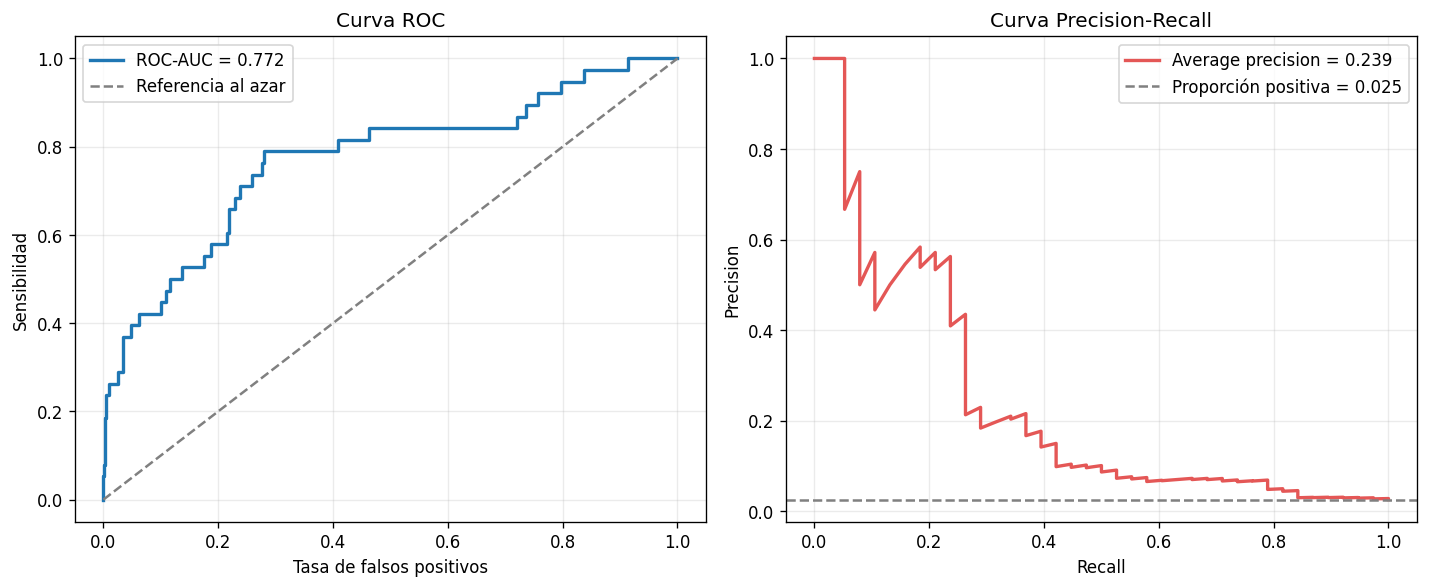

In [21]:
fpr_raro, tpr_raro, _ = roc_curve(
    y_raro_test,
    prob_raro,
)
precision_raro, recall_raro, _ = (
    precision_recall_curve(
        y_raro_test,
        prob_raro,
    )
)

fig, ejes = plt.subplots(
    1,
    2,
    figsize=(12, 5),
)

ejes[0].plot(
    fpr_raro,
    tpr_raro,
    linewidth=2,
    label=f"ROC-AUC = {auc_raro:.3f}",
)
ejes[0].plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="Referencia al azar",
)
ejes[0].set_title("Curva ROC")
ejes[0].set_xlabel(
    "Tasa de falsos positivos"
)
ejes[0].set_ylabel("Sensibilidad")
ejes[0].grid(alpha=0.25)
ejes[0].legend()

ejes[1].plot(
    recall_raro,
    precision_raro,
    linewidth=2,
    color="#E45756",
    label=(
        "Average precision "
        f"= {ap_raro:.3f}"
    ),
)
ejes[1].axhline(
    prevalencia_rara,
    linestyle="--",
    color="gray",
    label=(
        "Proporción positiva "
        f"= {prevalencia_rara:.3f}"
    ),
)
ejes[1].set_title(
    "Curva Precision-Recall"
)
ejes[1].set_xlabel("Recall")
ejes[1].set_ylabel("Precision")
ejes[1].grid(alpha=0.25)
ejes[1].legend()

plt.tight_layout()
plt.show()


Las dos curvas responden preguntas distintas. ROC observa sensibilidad frente a tasa de falsos positivos. Precision-Recall se concentra en la detección de la clase positiva y en la confiabilidad de las alertas.

`average_precision` resume la curva Precision-Recall, pero aquí solo la usamos como referencia breve. No profundizaremos todavía en sus variantes ni en procedimientos formales para comparar modelos.


### Una advertencia sobre las probabilidades

Un buen AUC indica que el modelo ordena razonablemente bien los casos. No garantiza que una salida de `0,80` corresponda exactamente a un 80% de frecuencia real.

El estudio de la calibración de probabilidades requiere herramientas específicas y queda fuera del alcance de este cuaderno. Por ahora, conviene recordar:

```text
AUC evalúa separación y ordenamiento.
No demuestra calibración perfecta.
```


## 11. Una pequeña exploración

Modificá la lista de umbrales y observá cómo se desplazan los puntos del modelo principal. Esta actividad no busca encontrar automáticamente el “mejor” valor, sino relacionar cada punto con las consecuencias de sus errores.


In [22]:
umbrales_actividad = [
    0.2,
    0.4,
    0.6,
    0.8,
]

resultados_actividad = []

for umbral in umbrales_actividad:
    predicciones = (
        prob_maligna >= umbral
    ).astype(int)

    vn_a, fp_a, fn_a, vp_a = (
        confusion_matrix(
            y_test,
            predicciones,
            labels=[0, 1],
        ).ravel()
    )

    resultados_actividad.append({
        "umbral": umbral,
        "VP": vp_a,
        "FP": fp_a,
        "FN": fn_a,
        "sensibilidad": (
            vp_a / (vp_a + fn_a)
        ),
        "especificidad": (
            vn_a / (vn_a + fp_a)
        ),
        "tasa_FP": (
            fp_a / (fp_a + vn_a)
        ),
    })

pd.DataFrame(
    resultados_actividad
).round(3)


,umbral,VP,FP,FN,sensibilidad,especificidad,tasa_FP
0,0.2,51,3,2,0.962,0.967,0.033
1,0.4,50,1,3,0.943,0.989,0.011
2,0.6,48,0,5,0.906,1.000,0.000
3,0.8,46,0,7,0.868,1.000,0.000


Al cambiar los valores, podés preguntarte:

- ¿qué umbral deja menos casos positivos sin detectar?;
- ¿cuál genera menos falsas alarmas?;
- ¿qué punto queda más cerca de la esquina superior izquierda?;
- ¿ese criterio geométrico coincide necesariamente con las necesidades del problema?;
- ¿qué matriz de confusión revisarías antes de tomar una decisión?;
- ¿cambiar los umbrales modifica el AUC del modelo?


## Cierre

Las probabilidades permiten estudiar un clasificador más allá de una única clase final. El umbral convierte esas probabilidades en decisiones y modifica el equilibrio entre sensibilidad y especificidad.

La curva ROC reúne ese comportamiento para muchos umbrales. AUC resume la capacidad general de separación y ordenamiento, pero no elige un punto de corte, no reemplaza la matriz de confusión y no garantiza probabilidades perfectamente calibradas.

Cuando la clase positiva es rara, la curva Precision-Recall puede aportar una mirada complementaria sobre la cobertura de los positivos y la calidad de las alertas. Evaluar responsablemente exige combinar métricas con las consecuencias reales de cada decisión.


## Para pensar

1. ¿Qué información conserva una probabilidad que se pierde al convertirla inmediatamente en una clase?
2. ¿Por qué bajar el umbral suele aumentar la sensibilidad y reducir la especificidad?
3. ¿Qué representa cada punto de una curva ROC?
4. ¿Qué significa que un modelo tenga un ROC-AUC cercano a `0,5`?
5. ¿Por qué un AUC alto no determina automáticamente qué umbral debe usarse?
6. ¿En qué situación una curva Precision-Recall podría ser más informativa que una curva ROC?
